In [2]:
# [CÉLULA 1] SETUP DO AMBIENTE E BIBLIOTECAS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configurando o visual dos gráficos para apresentação
sns.set_theme(style="whitegrid")

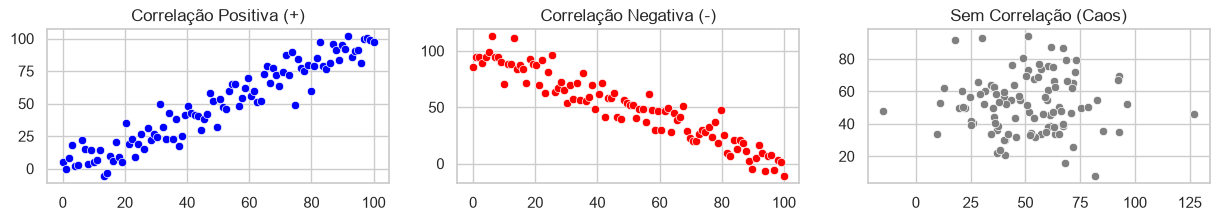

In [12]:
# [CÉLULA 2] SIMULAÇÃO: LENDO A NUVEM DE PONTOS
# Travando a aleatoriedade para o gráfico ser sempre igual
np.random.seed(42)
x_base = np.linspace(0, 100, 100)

# 1. Tendência Positiva
y_positivo = x_base + np.random.normal(0, 10, 100)

# 2. Tendência Negativa
y_negativo = 100 - x_base + np.random.normal(0, 10, 100)

# 3. Caos Total
x_caos = np.random.normal(50, 20, 100)
y_caos = np.random.normal(50, 20, 100)

# Plotando os cenários lado a lado
fig, axs = plt.subplots(1, 3, figsize=(15, 2))
sns.scatterplot(x=x_base, y=y_positivo, ax=axs[0], color='blue').set_title('Correlação Positiva (+)')
sns.scatterplot(x=x_base, y=y_negativo, ax=axs[1], color='red').set_title('Correlação Negativa (-)')
sns.scatterplot(x=x_caos, y=y_caos, ax=axs[2], color='gray').set_title('Sem Correlação (Caos)')
plt.show()

### [CÉLULA 3] O Ponto Cego de Pearson
O Coeficiente de Pearson avalia a força baseando-se em linhas retas. Quando o crescimento ocorre em curvas exponenciais, utilizamos o Ranking de Spearman.

**Fórmula de Pearson:**
$$ r = \frac{Cov(X,Y)}{s_x \cdot s_y} $$

Força segundo PEARSON (A Reta): 0.922
Força segundo SPEARMAN (O Ranking): 1.000


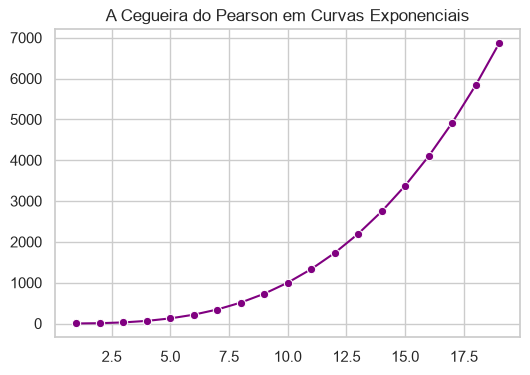

In [4]:
# [CÉLULA 4] O DUELO: PEARSON VS SPEARMAN
# Criando uma curva exponencial (y = x ao cubo)
x_curva = np.arange(1, 20)
y_curva = x_curva ** 3  
df_curva = pd.DataFrame({'X': x_curva, 'Y': y_curva})

# Calculando os coeficientes via Pandas
pearson = df_curva['X'].corr(df_curva['Y'], method='pearson')
spearman = df_curva['X'].corr(df_curva['Y'], method='spearman')

print(f"Força segundo PEARSON (A Reta): {pearson:.3f}")
print(f"Força segundo SPEARMAN (O Ranking): {spearman:.3f}")

plt.figure(figsize=(6,4))
sns.lineplot(x=x_curva, y=y_curva, marker='o', color='purple')
plt.title('A Cegueira do Pearson em Curvas Exponenciais')
plt.show()

In [5]:
# [CÉLULA 5] SETUP DA OFICINA PBL (CALIFORNIA HOUSING)
from sklearn.datasets import fetch_california_housing

# Baixando os dados embutidos na biblioteca
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Ajustando o preço para escala real (A base original estava reduzida)
df['Preco'] = data.target * 100000 

# Renomeando para português
df = df.rename(columns={
    'MedInc': 'Renda_Bairro',
    'HouseAge': 'Idade_Casa',
    'AveRooms': 'Qtd_Quartos',
    'AveBedrms': 'Qtd_Suites',
    'Population': 'Populacao',
    'AveOccup': 'Ocupacao_Media',
    'Latitude': 'Latitude',
    'Longitude': 'Longitude'
})

df.head()

,Renda_Bairro,Idade_Casa,Qtd_Quartos,Qtd_Suites,Populacao,Ocupacao_Media,Latitude,Longitude,Preco
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


### [CÉLULA 6] DESAFIO 1: A Matriz de Correlação
**O Problema (O Pedido do CEO):**
Qual característica estrutural ou social do imóvel tem o MAIOR poder estatístico para influenciar/ditar o seu Preço de Venda?

**Missão do Código:** Use a função `.corr()` do Pandas para gerar a matriz completa. Salve na variável `matriz_correlacao`. Imprima na tela apenas a coluna `Preco`, ordenando os valores do maior para o menor.

**Interpretação:** Adicione um comentário detalhando qual variável possui maior correlação com o preço e qual a relevância da 'Idade da Casa'.

In [ ]:
# [CÉLULA 7] RESOLUÇÃO - DESAFIO 1
matriz_correlacao = df.corr()
print(matriz_correlacao['Preco'].sort_values(ascending=False))

# ===== INTERPRETAÇÃO DOS RESULTADOS =====
# A 'Renda_Bairro' possui o maior peso preditivo positivo (~ 0.68).
# Fatores físicos como a 'Idade_Casa' demonstraram pouquíssima relevância linear (~ 0.10).
# O modelo matemático indica que a riqueza da vizinhança sobrepuja a estrutura do imóvel.

Preco             1.000000
Renda_Bairro      0.688075
Qtd_Quartos       0.151948
Idade_Casa        0.105623
Ocupacao_Media   -0.023737
Populacao        -0.024650
Longitude        -0.045967
Qtd_Suites       -0.046701
Latitude         -0.144160
Name: Preco, dtype: float64


### [CÉLULA 8] DESAFIO 2: O Mapa de Calor (Heatmap)
A leitura de matrizes numéricas extensas no terminal gera sobrecarga cognitiva e dificulta a visualização de padrões secundários.

**Missão do Código:** Importe `matplotlib` e `seaborn`. Transponha a matriz gerada no passo anterior para a função de Mapa de Calor (`heatmap`).

**Interpretação:** Analisando as cores geradas, cite duas colunas que possuem fortíssima ligação entre si (excluindo a coluna Preço) e justifique logicamente o porquê.

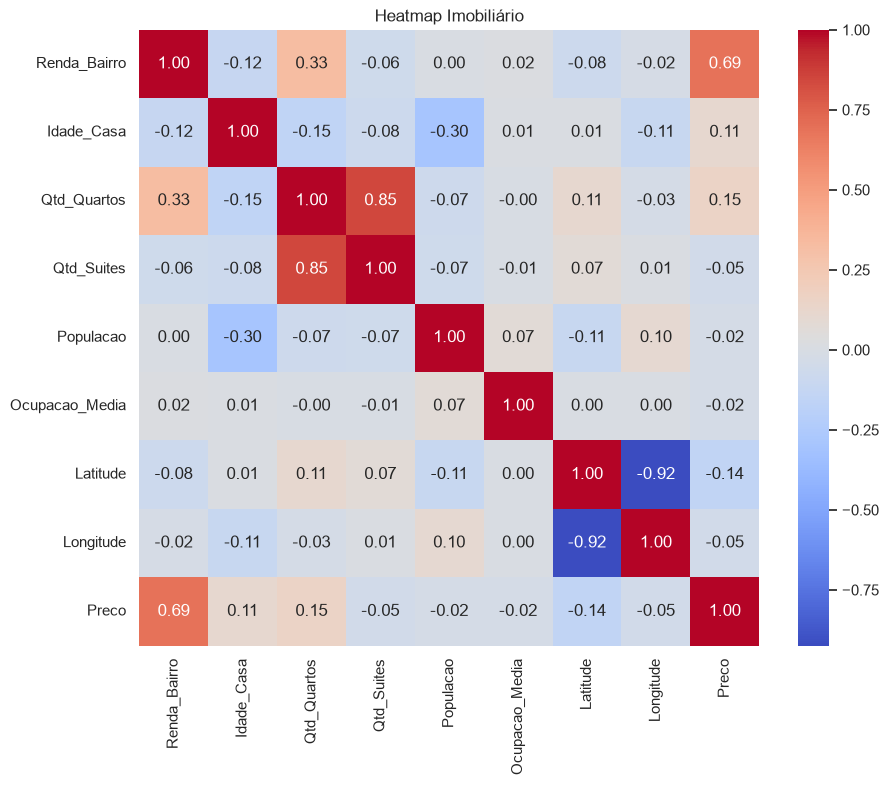

In [15]:
# [CÉLULA 9] RESOLUÇÃO - DESAFIO 2
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao,annot=True, cmap='coolwarm',  fmt=".2f")
plt.title('Heatmap Imobiliário')
plt.show()

# ===== INTERPRETAÇÃO DOS RESULTADOS =====
# O gráfico evidencia uma correlação extrema (+0.85) entre Qtd_Quartos e Qtd_Suites.
# Lógica: Projetos arquitetônicos com área para múltiplos quartos naturalmente alocam mais suítes.

### [CÉLULA 10] DESAFIO 3: A Prova Visual (Scatterplot)
Um coeficiente de +0.68 é considerado moderado/forte. Contudo, é necessário atestar a geometria da distribuição para evitar armadilhas visuais.

**Missão do Código:** Construa o Gráfico de Dispersão cruzando o vetor `Renda_Bairro` (X) contra o vetor `Preco` (Y). Adicione um nível de opacidade (`alpha=0.3`) nas coordenadas.

**Interpretação:** Avalie a angulação da nuvem. Existe algum ruído sistêmico visível na base de dados original?

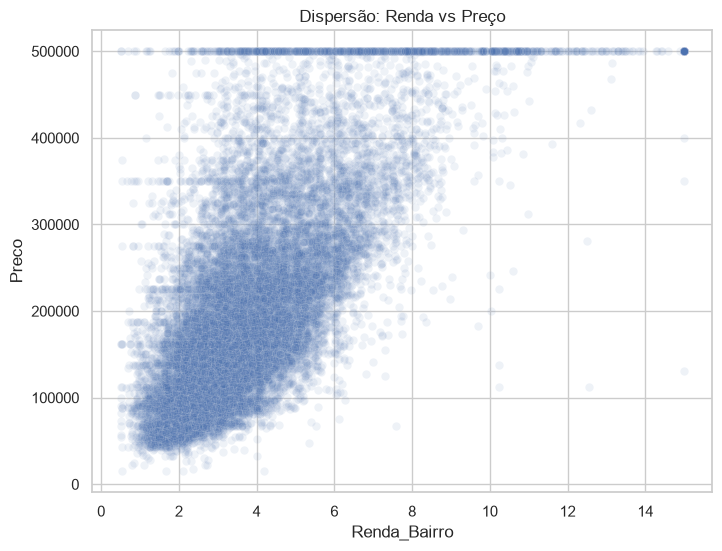

In [17]:
# [CÉLULA 11] RESOLUÇÃO - DESAFIO 3
plt.figure(figsize=(8, 6))#tamanho do gráfico
sns.scatterplot(data=df, x='Renda_Bairro', y='Preco', alpha=0.09) #alpha = transparência dos pontos
plt.title('Dispersão: Renda vs Preço')
plt.show()

# ===== INTERPRETAÇÃO DOS RESULTADOS =====
# A nuvem de pontos ascende de maneira linear, validando o número de Pearson.
# Ruído identificado: Há um traço horizontal massivo fixado em US$ 500.000.
# Isso indica um teto artificial do sistema de captação que censurou propriedades mais caras.

### [CÉLULA 12] DESAFIO 4 (BOSS): A Filtragem do Ruído
Sistemas limitados geram lixo estatístico, tracionando o vetor matemático e diluindo a força da correlação verdadeira.

**Missão do Código:** Estabeleça um filtro lógico no Pandas para compilar uma nova base `df_limpo` omitindo os registros de meio milhão ou mais. Realize a reextração de Pearson entre Renda e Preço.

**Interpretação:** Descreva qualitativamente o que ocorreu com a integridade matemática da correlação.

In [ ]:
# [CÉLULA 13] RESOLUÇÃO - DESAFIO 4

# 1. Filtro Booleano de Saneamento
df_limpo = df[df['Preco'] < 500000] #filtrando a tabela -como um filter data table!

# 2. Recálculo da Matriz
matriz_limpa = df_limpo.corr()
coeficiente_puro = matriz_limpa.loc['Renda_Bairro', 'Preco']

print(f"Força de Pearson anterior: {matriz_correlacao.loc['Renda_Bairro', 'Preco']:.4f}")
print(f"Força de Pearson com o ruído cortado: {coeficiente_puro:.4f}")

# ===== INTERPRETAÇÃO DOS RESULTADOS =====
# A correlação genuína ampliou de 0.68 para quase 0.70.
# Anomalias em bancos de dados enfraquecem a confiabilidade de modelos lineares.
# Higienizar a base é etapa mandatória antes de inserir os dados na Inteligência Artificial.

Força de Pearson anterior: 0.6881
Força de Pearson com o ruído cortado: 0.6467


#####RESUMAO DA AULA ACIMA !!!!!!!

df.corr()
O que faz (de forma simples): Calcula a correlação entre as colunas numéricas para ver se elas andam de mãos dadas (se uma sobe, a outra também sobe?).

df.corr(method='spearman')
O que faz (de forma simples): Semelhante ao anterior, mas olha para a posição (ordem) dos números e não apenas para o valor exacto. É óptimo quando a relação entre os dados não faz uma linha reta perfeita.

sns.heatmap(matriz, annot=True)
O que faz (de forma simples): Transforma uma tabela cheia de números numa grelha colorida (mapa de calor). O annot=True serve para escrever os números lá dentro para ficarem fáceis de ler à primeira vista

sns.scatterplot(x='A', y='B')
O que faz (de forma simples): Desenha um gráfico de pontos (dispersão) cruzando duas colunas para descobrirmos se formam algum padrão ou nuvem juntos

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'idade': [20, 30, 40, 50],
    'salario': [2000, 3000, 4000, 5000]
})

# Mostra a tabela de correlação entre as colunas
print(df.corr())

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'horas_estudo': [1, 2, 5, 10],
    'nota': [50, 60, 70, 95]
})

# Calcula a correlação baseada na ordem/ranking dos dados
print(df.corr(method='spearman'))

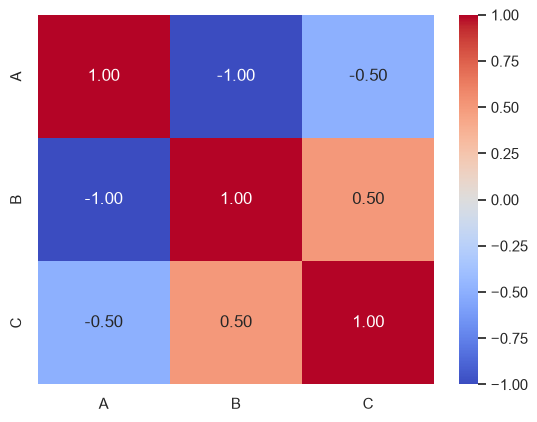

,A,B,C
0,1,3,2
1,2,2,3
2,3,1,1


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [3, 2, 1],
    'C': [2, 3, 1]
})
matriz = df.corr()

# Desenha o mapa de calor colorido com os números visíveis
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f")

plt.show()
df.head()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    'peso': [60, 70, 80, 90],
    'altura': [1.65, 1.70, 1.75, 1.80]
})

# Cria um gráfico de pontos cruzando o peso e a altura
sns.scatterplot(data=df, x='peso', y='altura')
plt.show()